<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/langgraph_tool_calling_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install tavily
!pip install langchain-mistralai

In [30]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from langchain.tools import tool
from tavily import TavilyClient
import os
from typing import Annotated , TypedDict
from langgraph.prebuilt import ToolNode , tools_condition


In [41]:
TAVILY_API_KEY = "put your api here"
OPENAPI_WEATHER_API_KEY = "put your api here"
CHAT_MISTRAL_API_KEY = "put your api here"

In [19]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY
)

In [20]:
@tool
def get_weather(city : str)->str:
  """Get weather of the city """
  url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={OPENAPI_WEATHER_API_KEY}&units=metric"

  response = requests.get(url)
  data = response.json()

  if str(data.get("cod")) !="200":
      return f"ERROR  :{data.get('message','Could not fetch weather')}"

  temp  = data["main"]["temp"]
  desc = data['weather'][0]['description']
  return f"weather in {city} : {desc} , {temp} degree celcius"

In [21]:
tavily_client = TavilyClient(api_key = TAVILY_API_KEY)
@tool
def get_news(city : str) ->str:
    """Get latest news about the city"""

    response = tavily_client.search(
        query = f"latest news in {city}",
        search_depth = "basic",
        max_results = 3
    )

    results = response.get("results",[])

    if not results:
        return f"No news found for {city}"

    news_list = []

    for r in results:
        title = r.get("title" , "No title")
        url = r.get("url","")
        snippet = r.get("content","")

        news_list.append(
        f"Title: {title}\nURL: {url}\nSnippet: {snippet[:100]}..."
        )

    return f"Latest News in {city}:\n\n" + "\n\n".join(news_list)

In [22]:
llm_with_tools = llm.bind_tools([get_weather , get_news])
tools={
    "get_weather" : get_weather,
    "get_news" : get_news
}

In [23]:
class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]

In [24]:
SYSTEM_PROMPT = SystemMessage(content="""You are a helpful assistant with access to two tools:
- get_weather: fetches current weather for a city
- news search tool: fetches latest news

Rules:
1. Use a tool ONLY when the user's request genuinely needs live/current data (weather, latest news). Don't call a tool for general knowledge questions.
2. When you get tool results back, present them in a clean, well-formatted, readable way (use markdown, bullet points, or tables where helpful — not a raw dump).
3. If a tool call is denied by the user, politely tell them you couldn't fetch the live data and offer to help another way.
4. Keep responses concise and directly useful.
""")

In [33]:
def tool(result):
  if result.tool_calls:

    tool_messages = []
    denied = False

    for tool_call in result.tool_calls:
        tool_name = tool_call['name']
        confirm = input(f"Agent wants to call {tool_name} with {tool_call['args']}. Approve (y/n): ")

        if confirm.lower() == "n":
            denied = True
            tool_messages.append(ToolMessage(
                content="Tool call denied by user.",
                tool_call_id=tool_call['id']
            ))
            continue

        tool_result = tools[tool_name].invoke(tool_call)

        tool_messages.append(tool_result)

  return  tool_messages


In [34]:
def chatbot(state: MessagesState):
    messages = state['messages']
    result = llm_with_tools.invoke([SYSTEM_PROMPT] + messages)

    if not result.tool_calls:
        print("BOT :", result.content)
        return {"messages": [result]}

    tool_messages = tool(result);

    followup = llm.invoke([SYSTEM_PROMPT] +  [result] + tool_messages)

    print('*' * 100)
    print(followup.content)
    print('*' * 100)

    final_ai_message = AIMessage(content=followup.content)
    return {"messages": [result] + tool_messages + [final_ai_message]}


In [35]:
def human(state : MessagesState):
    message = input("Ask your question...\n")
    return {"messages":[HumanMessage(content=message)]}

In [36]:
def human_approval(state : MessagesState):
  if state["messages"][-1].content.lower() == "exit":
    return END
  return "chatbot"

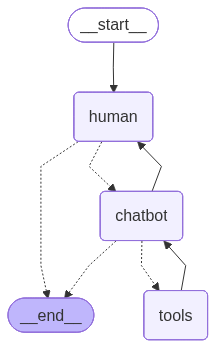

In [37]:
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
builder   = StateGraph(MessagesState)
builder.add_node("chatbot",chatbot)
builder.add_node("human",human)
builder.add_node("tools",tool)

builder.add_edge(START,"human")
builder.add_conditional_edges(
    "human",
    human_approval,
    {
        "chatbot": "chatbot",
        END: END,
    },
)
builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)
builder.add_edge("tools","chatbot")
builder.add_edge("chatbot","human")

memory = MemorySaver()
graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
config = {"configurable": {"thread_id": "1"}, "recursion_limit": 100}
output = graph.invoke({"messages": []}, config=config)
print("\n--- Full Conversation ---\n")
for m in output["messages"]:
    print(f"{m.type.upper()}: {m.content}\n")

Ask your question...
hello
BOT : Hi there! How can I help you today?
Ask your question...
what is weather in palampur
Agent wants to call get_weather with {'city': 'palampur'}. Approve (y/n): y
****************************************************************************************************
The weather in Palampur is currently experiencing light rain with a temperature of 30.74°C. Is there anything else I can assist you with?
****************************************************************************************************
Ask your question...
news of palampur
Agent wants to call get_news with {'city': 'palampur'}. Approve (y/n): y
****************************************************************************************************
Here are some of the latest news updates about Palampur:

1. **Latest Updates on and about Palampur**
   - Source: [Janta Serishta](https://jantaserishta.com/tags/palampur)
   - Summary: This source provides a collection of the latest updates and news re

In [40]:
from rich import print
for m in output["messages"]:
    print(m)

HumanMessage(
    content='hello',
    additional_kwargs={},
    response_metadata={},
    id='b646090f-546b-4f75-b224-a2a25d0745c6'
)

AIMessage(
    content='Hi there! How can I help you today?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 267,
            'total_tokens': 278,
            'completion_tokens': 11,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f2794-2d70-7743-afef-3aa185bbdd1b-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 267, 'output_tokens': 11, 'total_tokens': 278}
)

HumanMessage(
    content='what is weather in palampur',
    additional_kwargs={},
    response_metadata={},
    id='99daf03d-ba8a-49ec-a4e7-cbca4e6a51a6'
)

AIMessage(
    content='',
    additional_kwargs={
        'tool_calls': [
            {
                'id': 'PtMX77iQk',
                'type': 'function',
                'function': {'name': 'get_weather', 'arguments': '{"city": "palampur"}'},
                'index': 0
            }
        ]
    },
    response_metadata={
        'token_usage': {
            'prompt_tokens': 287,
            'total_tokens': 301,
            'completion_tokens': 14,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'tool_calls',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f2794-4a9b-75e1-8a35-479d809f08cd-0',
    tool_calls=[{'name': 'get_weather', 'args': {'city': 'palampur'}, 'id': 'PtMX77iQk', 'type': 'tool_call'}],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 287, 'output_tokens': 14, 'total_tokens': 301}
)

ToolMessage(
    content='weather in palampur : light rain , 30.74 degree celcius',
    name='get_weather',
    id='4cc0a497-20ca-4c68-a717-9ab5d98e63a5',
    tool_call_id='PtMX77iQk'
)

...

AIMessage(
    content='',
    additional_kwargs={
        'tool_calls': [
            {
                'id': 'k5oVHo79K',
                'type': 'function',
                'function': {'name': 'get_weather', 'arguments': '{"city": "manali"}'},
                'index': 0
            },
            {
                'id': '343ZwlwHZ',
                'type': 'function',
                'function': {'name': 'get_news', 'arguments': '{"city": "manali"}'},
                'index': 1
            }
        ]
    },
    response_metadata={
        'token_usage': {
            'prompt_tokens': 996,
            'total_tokens': 1021,
            'completion_tokens': 25,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'tool_calls',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f2795-1579-7543-bf0c-c0d6a82cb50a-0',
    tool_calls=[
        {'name': 'get_weather', 'args': {'city': 'manali'}, 'id': 'k5oVHo79K', 'type': 'tool_call'},
        {'name': 'get_news', 'args': {'city': 'manali'}, 'id': '343ZwlwHZ', 'type': 'tool_call'}
    ],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 996, 'output_tokens': 25, 'total_tokens': 1021}
)

ToolMessage(
    content='weather in manali : overcast clouds , 35.01 degree celcius',
    name='get_weather',
    id='89f829fe-0f42-49bf-a34d-c3964fb1d7ca',
    tool_call_id='k5oVHo79K'
)

ToolMessage(
    content='Latest News in manali:\n\nTitle: Manali News Today - Instagram\nURL: 
https://www.instagram.com/popular/manali-news-today?hl=en\nSnippet: Manali has seen multiple incidents in recent 
weeks, including a fatal hit-and-run on June 1 where a ...\n\nTitle: Today Manali News - Instagram\nURL: 
https://www.instagram.com/popular/today-manali-news?hl=en\nSnippet: Manali was in the news after a 60-year-old 
pedestrian was killed on June 1 when a drunk Delhi touris...\n\nTitle: manali news - The Indian Express\nURL: 
https://indianexpress.com/about/manali\nSnippet: MANALI NEWS. Manali tourists, Rajasthan · Tourist group from 
Rajasthan fined in Manali for reckless ...',
    name='get_news',
    id='c604e0c9-b791-4bf0-9b32-cd8895f53513',
    tool_call_id='343ZwlwHZ'
)

AIMessage(
    content="Here's the latest weather and news for Manali:\n\n**Weather:**\n- Conditions: Overcast clouds\n- 
Temperature: 35.01°C\n\n**News:**\n- Manali has seen multiple incidents in recent weeks, including a fatal 
hit-and-run on June 1 where a 60-year-old pedestrian was killed by a drunk Delhi tourist.\n- A tourist group from 
Rajasthan was fined in Manali for reckless behavior.",
    additional_kwargs={},
    response_metadata={},
    id='f7d0ecb9-8e13-4741-863f-82d3a675b14b',
    tool_calls=[],
    invalid_tool_calls=[]
)

HumanMessage(content='exit', additional_kwargs={}, response_metadata={}, id='848d0e82-6c97-44ae-a93f-5f52a0427405')